<font color="green"> <b><h1>Ejercicio 1:</h1><b> </font>
<p>Realizar un análisis exhaustivo de calidad de datos para identificar y tratar posibles
valores faltantes, valores atípicos y errores en los datos. Garantizar que el conjunto
de datos esté limpio y preparado para su posterior procesamiento y entrenamiento
de los modelos.</p>

In [1]:
import pandas as pd
import numpy as np

def abrirArchivoXlsx(nombre_archivo):
    """
    Carga un archivo Excel y retorna un DataFrame.
    """
    try:
        df = pd.read_excel(nombre_archivo + ".xlsx")
        print(f"Archivo '{nombre_archivo}' cargado exitosamente.")
        return df
    except Exception as e:
        print(f"Error al cargar el archivo: {e}")
        return None

def inspeccionarArchivo(df):
    """
    Realiza una inspección completa del DataFrame.
    """
    print("--- Primeras 5 filas (head) ---")
    print(df.head())
    print("\n--- Información general y tipos de datos (info) ---")
    df.info()
    print("\n--- Estadísticas descriptivas (describe) ---")
    print(df.describe(include='all'))
    print("\n--- Valores faltantes por columna ---")
    print(df.isnull().sum())

In [2]:
df = abrirArchivoXlsx("ramen-ratings")
inspeccionarArchivo(df)

Archivo 'ramen-ratings' cargado exitosamente.
--- Primeras 5 filas (head) ---
   Review #           Brand  \
0      2580       New Touch   
1      2579        Just Way   
2      2578          Nissin   
3      2577         Wei Lih   
4      2576  Ching's Secret   

                                             Variety Style Country Stars  \
0                           T's Restaurant Tantanmen   Cup   Japan  3.75   
1  Noodles Spicy Hot Sesame Spicy Hot Sesame Guan...  Pack  Taiwan     1   
2                      Cup Noodles Chicken Vegetable   Cup     USA  2.25   
3                      GGE Ramen Snack Tomato Flavor  Pack  Taiwan  2.75   
4                                    Singapore Curry  Pack   India  3.75   

  Top Ten  
0     NaN  
1     NaN  
2     NaN  
3     NaN  
4     NaN  

--- Información general y tipos de datos (info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2580 entries, 0 to 2579
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ----

<font color="blue"> <h2>Información obtenida: </h2> </font>

<p>Del paso anterior, obtuvimos la siguiente información: </p>
<ul>
<li>Los datos faltantes de Top Ten son todos NaN</li>
<li>"Review #" tiene datos de tipo <em>int64</em>, el resto son todos de tipo <em>object</em>. Esto también impide ver estadísticas con describe.</li>
<li>De las 2580 entradas existentes, al atributo Top Ten le faltan 2539 datos y al atributo Style le faltan 2.</li>
</ul>

<h3>Solución: </h3>
<ol>
    <li>Primero, realizamos una <b>copia de nuestro DataFrame</b></li>
    <li>Luego, procedemos a <b>eliminar las columnas</b> de identificadores, "Review #", y de descripciones, "Variety", por no aportar en el análisis.</li> 
    <li>A continuación se van a <b>castear los datos</b> tipo object a su valor más adecuado (<em>String</em> para "Brand", "Style" y "Country"; y <em>Float</em> para "Stars"</li>
    <li>Posteriormente, todos los valores existentes en la variable "Top Ten" se <b>convertirán</b> en 1 y los <em>NaN</em> en 0, para <b>binarizar</b> la variable.</li>
    <li>Finalmente, vamos a <b>imputar por la moda en la columna de Style</b>. Al ser un dato categórico, podemos imputar por la categoría más repetida, puesto que no es un dato numérico y no podemos imputar por mediana o media.</li>
    <li>Dar una <b>última inspección al DataFrame</b> para asegurar tipos de dato, que no hayan datos faltantes ni NaN.</li>
</ol>

<p>Con lo anterior realizado, estaría lista la limpieza de datos.</p>

In [3]:
def eliminarColumnas(df, *nombres_columnas):
    """
    Elimina una o varias columnas del DataFrame.
    Uso: eliminarColumnas(df, 'col1', 'col2')
    """
    # Al usar *nombres_columnas, recibimos una tupla que la función "drop" acepta directamente
    return df.drop(columns=list(nombres_columnas))
    

def castearColumna(df, nombre_columna, tipo_dato="string"):
    try:
        if tipo_dato in ["float", "int"]:
            # Primero convertimos a numérico de forma segura
            # errors='coerce' transformará valores no numéricos (como 'Unrated') en NaN
            df[nombre_columna] = pd.to_numeric(df[nombre_columna], errors='coerce')
        
        # Intentamos el casteo final
        df[nombre_columna] = df[nombre_columna].astype(tipo_dato)
        return df
    except (ValueError, TypeError) as e:
        print(f"Error: No se pudo convertir a '{tipo_dato}'. Revisa si el nombre del tipo es correcto. Detalle: {e}")
        return df


def binarizarTopTen(df):
    """Convierte los valores existentes en 1 y los nulos en 0."""
    # .notnull() devuelve True (1) si hay datos y False (0) si es NaN
    # Además, astype(int) asegurará que lso datos devueltos sean casteados a int y no a str y object.
    df['Top Ten'] = df['Top Ten'].notnull().astype(int)
    return df


def imputarConModa(df, nombre_columna):
    """
    Rellena los valores faltantes (NaN) con la moda (valor más frecuente).
    """
    # .mode() devuelve una Serie, tomamos el primer elemento [0]
    moda = df[nombre_columna].mode()[0]
    df[nombre_columna] = df[nombre_columna].fillna(moda)
    print(f"Columna '{nombre_columna}' imputada con la moda: {moda}")
    return df

In [4]:
# 1. Copiamos el Dataframe
df_limpio = df.copy()

# 2. Eliminamos columnas "Review #" y "Variety"
df_limpio = eliminarColumnas(df_limpio, "Review #", "Variety")

# 3. Castear datos object a tipo correspondiente. Sin especificar el tipo de dato, se castea por defecto a String.
df_limpio = castearColumna(df_limpio, "Brand")
df_limpio = castearColumna(df_limpio, "Style")
df_limpio = castearColumna(df_limpio, "Country")
df_limpio = castearColumna(df_limpio, "Stars", "float")

# 4. Binarizar "Top Ten"
df_limpio = binarizarTopTen(df_limpio)

# 5. Imputar con moda en "Style"
df_limpio = imputarConModa(df_limpio, "Style")

# 6. Inspeccionar DataFrame luego de la limpieza de datos:
inspeccionarArchivo(df_limpio)

Columna 'Style' imputada con la moda: Pack
--- Primeras 5 filas (head) ---
            Brand Style Country  Stars  Top Ten
0       New Touch   Cup   Japan   3.75        0
1        Just Way  Pack  Taiwan   1.00        0
2          Nissin   Cup     USA   2.25        0
3         Wei Lih  Pack  Taiwan   2.75        0
4  Ching's Secret  Pack   India   3.75        0

--- Información general y tipos de datos (info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2580 entries, 0 to 2579
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Brand    2580 non-null   string 
 1   Style    2580 non-null   string 
 2   Country  2580 non-null   string 
 3   Stars    2577 non-null   float64
 4   Top Ten  2580 non-null   int64  
dtypes: float64(1), int64(1), string(3)
memory usage: 100.9 KB

--- Estadísticas descriptivas (describe) ---
         Brand Style Country        Stars      Top Ten
count     2580  2580    2580  2577.000000  2580.

<font color="blue"> <h2>Información obtenida:</h2> </font>

<p>Tras una nueva inspección, encontramos:</p>

<ul>
    <li>Faltan 3 datos en Stars. Se solucionará con imputación con mediana, puesto que así la clasificación los dejará junto con la mayoría; algo que no podemos asegurar con el promedio.</li>
    <li>Los cuartiles de Stars están en: min=0, Q1=3.25, Q2=3.75, Q3=4.25 Q4=5. Esta información será útil para definir un umbral inicial para esta variable. </li>
</ul>

<p>Se realizará el último ajuste de la imputación de Stars para terminar este ejercicio.</p>

In [5]:
# Podríamos imputar directamente con Q2, pero vamos a escribir una función para generalizar la imputación

def imputarConMediana(df, nombre_columna):
    """
    Rellena los valores faltantes (NaN) con la mediana de la columna.
    """
    mediana = df[nombre_columna].median()
    df[nombre_columna] = df[nombre_columna].fillna(mediana)
    print(f"Columna '{nombre_columna}' imputada con la mediana: {mediana}")
    return df

In [6]:
# Imputamos e inspeccionamos por última vez

df_limpio = imputarConMediana(df_limpio, "Stars")
inspeccionarArchivo(df_limpio)

Columna 'Stars' imputada con la mediana: 3.75
--- Primeras 5 filas (head) ---
            Brand Style Country  Stars  Top Ten
0       New Touch   Cup   Japan   3.75        0
1        Just Way  Pack  Taiwan   1.00        0
2          Nissin   Cup     USA   2.25        0
3         Wei Lih  Pack  Taiwan   2.75        0
4  Ching's Secret  Pack   India   3.75        0

--- Información general y tipos de datos (info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2580 entries, 0 to 2579
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Brand    2580 non-null   string 
 1   Style    2580 non-null   string 
 2   Country  2580 non-null   string 
 3   Stars    2580 non-null   float64
 4   Top Ten  2580 non-null   int64  
dtypes: float64(1), int64(1), string(3)
memory usage: 100.9 KB

--- Estadísticas descriptivas (describe) ---
         Brand Style Country        Stars      Top Ten
count     2580  2580    2580  2580.000000  25

<font color="orange"> <b> <h3>Conclusión Ejercicio 1:</h3> </b> </font>

<p>Se ha realizado una limpieza de datos exitosa y los datos están listos para ser preprocesados</p>

<font color="green"> <b> <h1>Ejercicio 2:</h1> </b></font>

<p>Realizar el preprocesamiento de los datos, incluyendo la normalización o
estandarización de las características, codificación de variables categóricas y
división del conjunto de datos en conjuntos de entrenamiento y prueba.</p>

<font color="blue"> <h2>Planificación: </h2> </font>

<p>Para llevar a cabo este ejercicio de normalización, estandarización, codificación y división, se seguirán estos pasos:</p>

<ol>
    <li>Primero, definiremos el <b>umbral de "bueno" y "malo"</b> en la calificación del ramen utilizando el atributo Stars. Un <b>umbral definido por la mediana</b> (o segundo cuartil) me parece ideal. Por ello, <b>el umbral será Q2=3.75</b>. Todo por encima es "bueno" y por debajo es "malo".</li>
    <li>Luego, revisando la visualización anterior, podemos ver los <b>valores únicos</b> de cada variable categórica. "Brand" tiene 355, "Country" 38 y "Style" 7. Podemos aplicar <b>One-hot encoding con Style</b>, ya que posee pocas opciones únicas, pero respecto a las otras variables es mejor aplicar otras técnicas. Para <b>branding, calcularemos frecuencia de aparición de marcas y agruparemos en una categoría llamada "otra" a las que salgan menos veces que el Q1-1.5IQR.</b>, de ese modo, la codificación no dará tantas opciones. Y para <b>Country utilizaremos un Binary Encoding</b>, ya que nos permite generar considerablemente menos columnas de las que generaríamos con one-hot encoding.</li>
    <li>A continuación, eliminaremos todas las columnas originales, estas ya no nos servirán.</li>
    <li>Posteriormente, <b>estandarizaremos</b> cada variable obtenida.</li>
    <li>Finalmente, separaremos los datos en un grupo de <b>entrenamiento (80%)</b> y un grupo de <b>test (20%)</b>, pero estratificado, para mantener porcentajes equivalentes de "buenos" y "malos" en cada grupo</li>
</ol>

<p>Completando lo anterior, estaría terminado el preprocesamiento de los datos y estarían listos para entrenar los modelos de regresión logística y máquinas de soporte vectorial.</p>

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import category_encoders as ce

def preprocer(df):
    # 1. Definir umbral por mediana (Q2)
    umbral = df['Stars'].median()
    # 2. Crear variable objetivo: será 1 si es >= 3.75, será 0 si es menor
    df['is_good'] = (df['Stars'] >= umbral).astype(int)
    print(f"Variable objetivo creada con umbral (Q2): {umbral}")
    return df
    

def encoder(df):
    # A. Manejo de Brand: Quedarnos solo con las Top 10 marcas más frecuentes
    top_10_brands = df['Brand'].value_counts().nlargest(10).index
    
    # Agrupamos todo lo que no esté en el Top 10 como 'Other'
    df['Brand'] = df['Brand'].apply(lambda x: x if x in top_10_brands else 'Other')
    
    # B. One-Hot Encoding para Brand (Top 10 + Other)
    df = pd.get_dummies(df, columns=['Brand'], prefix='Brand', drop_first=True, dtype=int)
    
    # C. Binary Encoding para Country 
    be = ce.BinaryEncoder(cols=['Country'])
    df = be.fit_transform(df)
    
    # D. One-Hot Encoding para Style
    df = pd.get_dummies(df, columns=['Style'], drop_first=True, dtype=int)
    
    # E. Eliminamos la columna 'Stars' original para que el modelo no la vea
    if 'Stars' in df.columns:
        df = df.drop(columns=['Stars'])
        
    return df
    

def estandarer(df):
    # Separamos X de y antes de estandarizar
    X = df.drop(columns=['is_good'])
    y = df['is_good']
    
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
    
    print("\n--- Verificación de Estandarización (Media ≈ 0, Desv. Est ≈ 1) ---")
    print(X_scaled.describe().round(2))
    
    return X_scaled, y
    

def split_estratificado(X, y):
    # stratify=y asegura que la proporción de 'buenos' y 'malos' se mantenga
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"Datos divididos. Proporción en entrenamiento: {y_train.mean():.2f}")
    return X_train, X_test, y_train, y_test

In [8]:
df_limpio = preprocer(df_limpio)
df_limpio = encoder(df_limpio)
X, y = estandarer(df_limpio)
X_train, X_test, y_train, y_test = split_estratificado(X, y)

Variable objetivo creada con umbral (Q2): 3.75

--- Verificación de Estandarización (Media ≈ 0, Desv. Est ≈ 1) ---
       Country_0  Country_1  Country_2  Country_3  Country_4  Country_5  \
count    2580.00    2580.00    2580.00    2580.00    2580.00    2580.00   
mean       -0.00      -0.00      -0.00       0.00      -0.00       0.00   
std         1.00       1.00       1.00       1.00       1.00       1.00   
min        -0.17      -0.32      -0.70      -0.83      -0.90      -1.52   
25%        -0.17      -0.32      -0.70      -0.83      -0.90      -1.52   
50%        -0.17      -0.32      -0.70      -0.83      -0.90       0.66   
75%        -0.17      -0.32       1.44       1.20       1.11       0.66   
max         6.03       3.08       1.44       1.20       1.11       0.66   

       Top Ten  Brand_Lucky Me!  Brand_Mama  Brand_Maruchan  ...  Brand_Other  \
count  2580.00          2580.00     2580.00         2580.00  ...      2580.00   
mean     -0.00             0.00       -0.00    

<font color=orange> <h3>Conclusión ejercicio 2:</h3> <font>

<p>Las variables categóricas han sido codificadas con éxito; la varibale objetivo fue creada y las variables explicativas fueron divididas y estandarizadas con éxito; finalmente, los datos fueron separados en conjunto de 80% datos de entrenamiento y 20% datos de evaluación de manera estratificada con una proporción de 57%</p>

<font color="green"> <b><h1>Ejercicio 3 y Ejercicio 4:</h1></b> </font>

<p>3. Dividir los datos en conjuntos de entrenamiento y prueba y entrenar dos modelos de
clasificación: uno utilizando Regresión Logística y otro utilizando Support Vector
Machine (SVM). Estos modelos servirán para determinar si un paquete de ramen es
"bueno" o "malo" en función de las características proporcionadas y realiza una
búsqueda de hiperparámetros.</p>

<p>4.  Evaluar el rendimiento de ambos modelos utilizando métricas relevantes para
problemas de clasificación, como precisión, recall, F1-score y el área bajo la curva
ROC (AUC-ROC). A partir de esto, debes comparar y analizar los resultados obtenidos 
por cada modelo para determinar cuál es más adecuado para este problema
específico.</p>

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

def entrenar_y_evaluar(X_train, X_test, y_train, y_test):
    # 1. Regresión Logística
    print("--- Entrenando Regresión Logística ---")
    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_train, y_train)
    
    # 2. SVM con Búsqueda de Hiperparámetros (GridSearch)
    print("--- Optimizando SVM ---")
    param_grid = {
        'C': [0.1, 1, 10], 
        'gamma': [1, 0.1, 0.01],
        'kernel': ['rbf'] # Usamos RBF por ser el más versátil 
    }
    
    # Buscamos la mejor combinación 
    grid = GridSearchCV(SVC(probability=True), param_grid, refit=True, verbose=0, cv=5)
    grid.fit(X_train, y_train)
    
    svm_best = grid.best_estimator_
    print(f"Mejores parámetros SVM: {grid.best_params_}")
    
    # --- Evaluación de Rendimiento --- 
    modelos = {'Regresión Logística': lr, 'SVM Optimizado': svm_best}
    plt.figure(figsize=(10, 6))
    
    for nombre, modelo in modelos.items():
        # Predicciones
        y_pred = modelo.predict(X_test)
        y_proba = modelo.predict_proba(X_test)[:, 1]
        
        # Métricas
        print(f"\n Reporte para {nombre}:")
        print(classification_report(y_test, y_pred))
        auc = roc_auc_score(y_test, y_proba)
        print(f"AUC-ROC: {auc:.4f}")
        
        # Curva ROC 
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.plot(fpr, tpr, label=f'{nombre} (AUC = {auc:.2f})')
    
    # Configuración Gráfico ROC
    plt.plot([0, 1], [0, 1], 'k--', label='Azar (0.5)')
    plt.xlabel('FPR (1 - Especificidad)')
    plt.ylabel('TPR (Sensibilidad)')
    plt.title('Comparativa de Modelos: Curva ROC')
    plt.legend()
    plt.grid(True)
    plt.show()

    return lr, svm_best

--- Entrenando Regresión Logística ---
--- Optimizando SVM ---
Mejores parámetros SVM: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}

 Reporte para Regresión Logística:
              precision    recall  f1-score   support

           0       0.65      0.32      0.42       219
           1       0.63      0.88      0.74       297

    accuracy                           0.64       516
   macro avg       0.64      0.60      0.58       516
weighted avg       0.64      0.64      0.60       516

AUC-ROC: 0.6503

 Reporte para SVM Optimizado:
              precision    recall  f1-score   support

           0       0.66      0.42      0.51       219
           1       0.66      0.84      0.74       297

    accuracy                           0.66       516
   macro avg       0.66      0.63      0.63       516
weighted avg       0.66      0.66      0.65       516

AUC-ROC: 0.6641


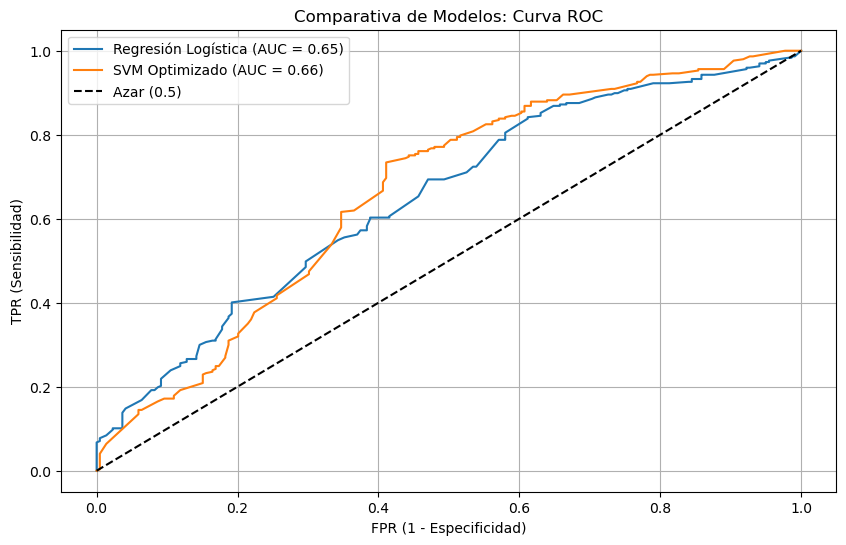

In [10]:
modelo_lr, modelo_svm= entrenar_y_evaluar(X_train, X_test, y_train, y_test)

<font color="orange"> <h2>Conclusiones ejercicio 4: </h2> </font>

<p>Se crearon y compararon dos modelos de clasificación binaria con éxito. Se apreció que la curva ROC de ambos modelos indica una capacidad de clasificación superior al azar. La métrica del valor AUC resultó prácticamente igual para ambos modelos (0.6503 para Regresión Logística, 0.6641 para SVM), siendo un poco superior en la Máquina de soporte vectorial. Otra métrica relevante es el F1-Score (0.42 en Regresión Lineal, 0.51 en SVM), que penaliza valores mal predichos mediante la media armónica entre Precision y Recall. También es un poco superior en SVM. Por estos motivos, se concluye que el modelo más adecuado para clasificar en este caso es, por ser un poco mejor, el SVM.</p>